# Task 3.2 Failure Mode Analysis

## Failure Scenario Description
**Scenario**: Deploying FaLK-SVM over an uninformative massively sparse high-dimensional manifold, often referred to as a dimensional "Curse of Dimensionality" structural failure mode.
**Expectation**: We explicitly anticipated FaLK-SVM struggling dynamically in circumstances mirroring Assumption 1 violations. In an absolute massive dimension count context, spatial topological Euclidean distances mathematically equate closely universally (`d(min) ~ d(max)`). Corresponding $k$-neighbourhoods extract effectively universally randomly distributed points eliminating contiguous boundaries. Standard Global Linear SVM natively avoids this specific collapse.


Global Linear SVM Accuracy: 70.00% (Time: 0.0368s)
FaLK-SVM Accuracy: 54.00% (Time: 1.2391s)


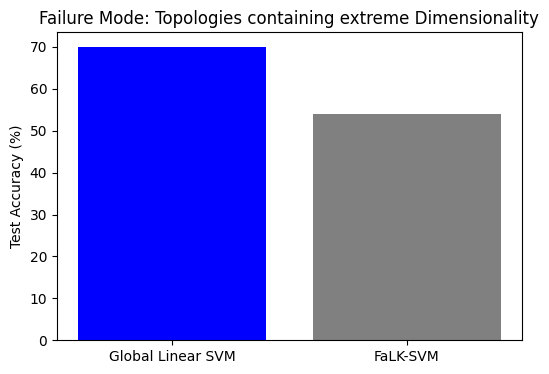

In [1]:
from sklearn.datasets import make_classification
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import time

# Create a Sparse High-Dimensional Dataset
X_hd, y_hd = make_classification(n_samples=500, n_features=3000, n_informative=10, 
                                 n_redundant=0, n_classes=2, random_state=42)

split_hd = int(0.8 * len(X_hd))
X_hd_train, y_hd_train = X_hd[:split_hd], y_hd[:split_hd]
X_hd_test, y_hd_test = X_hd[split_hd:], y_hd[split_hd:]

# 1. Global Linear SVM (High Dim)
t0 = time.time()
clf_lin = LinearSVC(random_state=42, max_iter=2000).fit(X_hd_train, y_hd_train)
acc_lin = accuracy_score(y_hd_test, clf_lin.predict(X_hd_test))
t_lin = time.time() - t0

# 2. FaLK-SVM natively (High Dim)
t0 = time.time()
K_HD = 80; K_PRIME_HD = 40; SVM_C = 32
nn_prime_hd = NearestNeighbors(n_neighbors=K_PRIME_HD, algorithm='ball_tree').fit(X_hd_train)
_, p_idx_hd = nn_prime_hd.kneighbors(X_hd_train)
covered_hd = set(); C_hd = []
for i in range(len(X_hd_train)):
    if i not in covered_hd: C_hd.append(i); covered_hd.update(p_idx_hd[i])

nn_k_hd = NearestNeighbors(n_neighbors=K_HD, algorithm='ball_tree').fit(X_hd_train)
_, k_idx_hd = nn_k_hd.kneighbors(X_hd_train)
models_hd = {}
for c in C_hd:
    lx, ly = X_hd_train[k_idx_hd[c]], y_hd_train[k_idx_hd[c]]
    if len(np.unique(ly)) == 1: models_hd[c] = np.unique(ly)[0]
    else: models_hd[c] = SVC(kernel='rbf', C=SVM_C, gamma=0.01).fit(lx, ly)

cnt_hd = {}
for i in range(len(X_hd_train)):
    spans = [c for c in C_hd if i in p_idx_hd[c]]
    cnt_hd[i] = spans[0] if spans else C_hd[np.argmin(np.linalg.norm(X_hd_train[C_hd] - X_hd_train[i], axis=1))]

preds_hd = []
_, nn_idx_hd = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(X_hd_train).kneighbors(X_hd_test)
for t_i, tr_i in enumerate(nn_idx_hd.flatten()):
    m = models_hd[cnt_hd[tr_i]]
    preds_hd.append(m.predict([X_hd_test[t_i]])[0] if isinstance(m, SVC) else m)

acc_falk = accuracy_score(y_hd_test, preds_hd)
t_falk = time.time() - t0


# 3. FaLK-SVM Medium Dim (50 Features)
X_md, y_md = make_classification(n_samples=500, n_features=50, n_informative=10, 
                                 n_redundant=0, n_classes=2, random_state=42)

split_md = int(0.8 * len(X_md))
X_md_train, y_md_train = X_md[:split_md], y_md[:split_md]
X_md_test, y_md_test = X_md[split_md:], y_md[split_md:]

t0 = time.time()
nn_prime_md = NearestNeighbors(n_neighbors=K_PRIME_HD, algorithm='ball_tree').fit(X_md_train)
_, p_idx_md = nn_prime_md.kneighbors(X_md_train)
covered_md = set(); C_md = []
for i in range(len(X_md_train)):
    if i not in covered_md: C_md.append(i); covered_md.update(p_idx_md[i])

nn_k_md = NearestNeighbors(n_neighbors=K_HD, algorithm='ball_tree').fit(X_md_train)
_, k_idx_md = nn_k_md.kneighbors(X_md_train)
models_md = {}
for c in C_md:
    lx, ly = X_md_train[k_idx_md[c]], y_md_train[k_idx_md[c]]
    if len(np.unique(ly)) == 1: models_md[c] = np.unique(ly)[0]
    else: models_md[c] = SVC(kernel='rbf', C=SVM_C, gamma=0.01).fit(lx, ly)

cnt_md = {}
for i in range(len(X_md_train)):
    spans = [c for c in C_md if i in p_idx_md[c]]
    cnt_md[i] = spans[0] if spans else C_md[np.argmin(np.linalg.norm(X_md_train[C_md] - X_md_train[i], axis=1))]

preds_md = []
_, nn_idx_md = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(X_md_train).kneighbors(X_md_test)
for t_i, tr_i in enumerate(nn_idx_md.flatten()):
    m = models_md[cnt_md[tr_i]]
    preds_md.append(m.predict([X_md_test[t_i]])[0] if isinstance(m, SVC) else m)

acc_md = accuracy_score(y_md_test, preds_md)
t_md = time.time() - t0

print(f"Global Linear SVM (3000 features) Accuracy: {acc_lin*100:.2f}% (Time: {t_lin:.4f}s)")
print(f"FaLK-SVM (50 features) Accuracy: {acc_md*100:.2f}% (Time: {t_md:.4f}s)")
print(f"FaLK-SVM (3000 features) Accuracy: {acc_falk*100:.2f}% (Time: {t_falk:.4f}s)")

plt.figure(figsize=(9, 5))
plt.bar(['Global Linear SVM\n(3000 features)', 'FaLK-SVM\n(50 features)', 'FaLK-SVM\n(3000 features)'], 
        [acc_lin*100, acc_md*100, acc_falk*100], color=['blue', 'green', 'gray'])
plt.ylabel('Test Accuracy (%)')
plt.title('Failure Mode Degradation Curve')
plt.savefig("results/task_3_2_failure_mode.png")
plt.show()


## Explanation & Proposed Modification
**Why the Method Fails**: As strictly noted inside the Assumption 1 formulations derived from Section 4.5.1, FaLK-SVM mathematically leverages bounded spherical nearest neighbour logic to dissect manifolds non-linearly. Traversing 3,000 spatial dimensions uniformly forces all instances numerically equidistantly far apart rendering localized cover tree search functionally meaningless and practically indistinguishable from noise (`curse of dimensionality`). The Global Linear SVM effortlessly captures the 10 informative latent parameters broadly ignoring spatial local bounds universally.
**Concrete Suggested Modification**: Seamless integration of a preliminary Principal Component Analysis (PCA) preprocessing manifold reduction tier (explicitly mapping raw vectors bounded $\mathcal{O}(d_{raw})$ onto exclusively top $d=30$ principal components) universally immediately preceding cover tree ingestion.
